In [ ]:
import numpy as np
import vowpalwabbit
from vowpalwabbit import Workspace, PredictionType

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from cb_sim import (
    BanditEnv, K, ACTION_NAMES, FEATURE_NAMES, FEATURE_STATS, W_TRUE, sigmoid,
)
from cb_vw import vw_features, sample_from_probs, run_bandit

print("vowpalwabbit version:", getattr(vowpalwabbit, "__version__", "unknown"))

/opt/homebrew/Cellar/micromamba/2.5.0/envs/shop-ml-vw310/lib/python3.10/site-packages/vowpalwabbit/version.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


vowpalwabbit version: 9.10.0


# 1. Contextual Bandits for Re-engagement Notifications

## Scenario

A user has gone silent for $N$ weeks.  We send **one** re-engagement push notification (or email) to bring them back.  The system must decide **which message variant** to send, using what it knows about the user.

## Formal setup

| Component | Symbol | Description |
|-----------|--------|-------------|
| **Context** | $x$ | Features describing the dormant user (e.g. `lifetime_purchases`, `days_as_customer`) |
| **Action** | $a \in \{1,\dots,K\}$ | Which message variant to send |
| **Reward** | $r \in \{0, 1\}$ | Whether the user clicks through (1) or ignores (0) |

At each round the system observes a context $x$, chooses an action $a$, and receives a **bandit reward**: the outcome for the chosen action only.  We never see what *would have happened* under a different action (the fundamental **counterfactual** problem).

## Ground-truth click model (unknown to the learner)

Each (user, message) pair has an independent click probability:

$$
p(\text{click} \mid x, a) \;=\; \sigma\!\bigl(W_{\text{TRUE}}[a] \cdot x\bigr)
$$

where $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the sigmoid function, and $x = [1, \;\text{lifetime\_purchases\_std}, \;\text{days\_as\_customer\_std}]$.

These probabilities are **independent Bernoulli means** — they do **not** sum to 1 across actions.  They represent "how likely is a click *if* we send this particular message to this particular user."

### Role of the bias term

The leading 1 in $x$ is a **bias/intercept** term.  Each row of $W_{\text{TRUE}}$ has the form $[\text{bias}, \; w_{\text{purchases}}, \; w_{\text{days}}]$, so the logit expands to:

$$
z_a(x) = \underbrace{W[a, 0]}_{\text{bias}} \cdot 1 \;+\; W[a, 1] \cdot \text{purchases\_std} \;+\; W[a, 2] \cdot \text{days\_std}
$$

When both features are at their population mean (standardized = 0), the feature terms vanish and we're left with $p(\text{click}) = \sigma(\text{bias})$.  This gives each action its **baseline CTR** — the click rate for a completely average user:

| Action | Bias | $\sigma$(bias) |
|--------|------|---------------|
| "See what's new" | −2.5 | **7.6%** |
| "Personalized picks" | −2.5 | **7.6%** |
| "We miss you" | −2.8 | **5.7%** |
| "Trending picks" | −2.2 | **10.0%** |

These baselines are realistic for re-engagement notifications (~6–10%).  The feature weights then push CTRs up or down from this baseline depending on the user's profile.

## Oracle decision boundaries

The **oracle policy** always picks the action with the highest true CTR:

$$
a^*(x) \;=\; \arg\max_{a} \; W_{\text{TRUE}}[a] \cdot x
$$

(We can drop the sigmoid because it's strictly monotonic — it preserves the ranking.)

The boundary between any two actions $a$ and $b$ is where their logits tie:

$$
W_{\text{TRUE}}[a] \cdot x \;=\; W_{\text{TRUE}}[b] \cdot x
\quad\Longleftrightarrow\quad
\bigl(W_{\text{TRUE}}[a] - W_{\text{TRUE}}[b]\bigr) \cdot x \;=\; 0
$$

This is a **linear equation** in $x$, so every pairwise boundary is a straight line.  The result is a partition of the feature space into convex regions — one per winning action.

> **The bandit's job** is to discover these regions through exploration and reward feedback, *without* ever knowing $W_{\text{TRUE}}$.  The gap between the oracle's CTR and the bandit's CTR is the **regret**.

## Reading the CTR profiles

Each curve shows how one message's click probability changes as we sweep a single feature, holding the other at its population mean.

**CTR vs. purchase history** (left panel)
- **"Personalized picks"** rises steeply — more purchase history gives the system better data to personalize with, so the message lands harder.
- **"See what's new"** rises more gently — frequent buyers are curious about new inventory, but the effect is weaker.
- **"We miss you"** *decreases* — emotional appeals don't resonate as well with transactional power shoppers.
- **"Trending picks"** decreases gently — social proof matters less to users who already know what they want.

**CTR vs. account age** (right panel)
- **"We miss you"** climbs steeply — the longer someone's been a customer, the more an emotional appeal feels genuine rather than generic.
- **"Personalized picks"** rises moderately — longer tenure means more data to personalize with.
- **"See what's new"** *drops* — a long-tenured user has probably seen most of what's new; this framing works better for recently-lapsed users.
- **"Trending picks"** drops gently — social proof becomes less compelling over time for established customers.

Baseline CTRs around the population mean sit at **~6–10%**, realistic for re-engagement notifications. The best oracle matches peak around **30–40%** for extreme users (rare, but plausible for the tail of the distribution).

In [10]:
# Initialize the environment and inspect its configuration.
env = BanditEnv(seed=0)

print("Actions:")
for a in range(1, K + 1):
    print(f"  {a}: {ACTION_NAMES[a]}")

print(f"\nFeatures: {FEATURE_NAMES}")
print(f"\nTrue weight matrix W_TRUE (rows=actions, cols=[bias, {', '.join(FEATURE_NAMES)}]):")
for a in range(1, K + 1):
    print(f"  {ACTION_NAMES[a]:30s}  {W_TRUE[a-1]}")

# Sample a few users and show the oracle's best action for each.
x, raw = env.sample_context()
print(f"\nSample user: {raw}")
best = env.oracle_action(x)
for a in range(1, K + 1):
    marker = " ← best" if a == best else ""
    print(f"  {ACTION_NAMES[a]:30s}  p(click) = {env.click_prob(x, a):.3f}{marker}")

for _ in range(5):
    x, raw = env.sample_context()
    best = env.oracle_action(x)
    ctrs = {a: env.click_prob(x, a) for a in range(1, K + 1)}
    print(f"purchases={raw['lifetime_purchases']:2d}  customer_days={raw['days_as_customer']:4d}  "
          f"best → {ACTION_NAMES[best]:34s}  CTRs={[round(ctrs[a], 3) for a in range(1, K+1)]}")

Actions:
  1: See what's new since you left
  2: Your personalized picks await
  3: We miss you! Come back
  4: Trending picks just for you

Features: ['lifetime_purchases', 'days_as_customer']

True weight matrix W_TRUE (rows=actions, cols=[bias, lifetime_purchases, days_as_customer]):
  See what's new since you left   [-2.5  0.4 -0.7]
  Your personalized picks await   [-2.5  0.7  0.4]
  We miss you! Come back          [-2.8 -0.4  1. ]
  Trending picks just for you     [-2.2 -0.2 -0.4]

Sample user: {'lifetime_purchases': 2, 'days_as_customer': 30}
  See what's new since you left   p(click) = 0.094
  Your personalized picks await   p(click) = 0.067
  We miss you! Come back          p(click) = 0.042
  Trending picks just for you     p(click) = 0.112 ← best
purchases= 7  customer_days= 370  best → Your personalized picks await       CTRs=[0.04, 0.236, 0.162, 0.046]
purchases= 2  customer_days= 502  best → We miss you! Come back              CTRs=[0.016, 0.17, 0.376, 0.042]
purchases= 3 

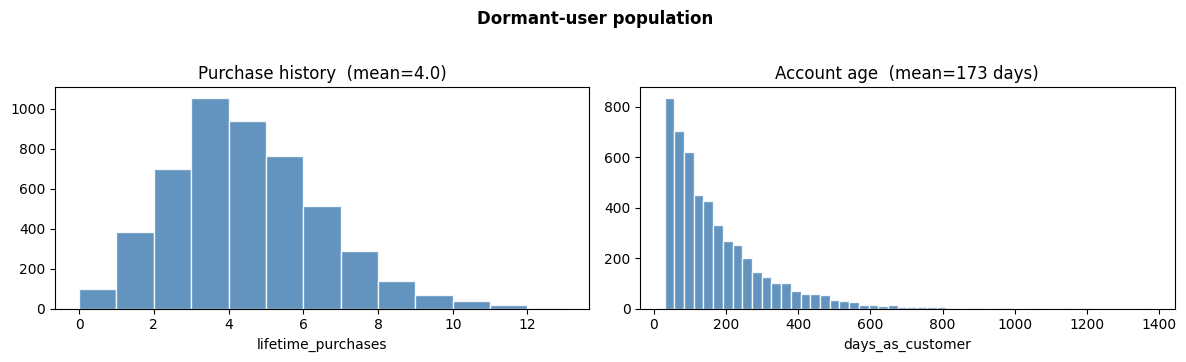

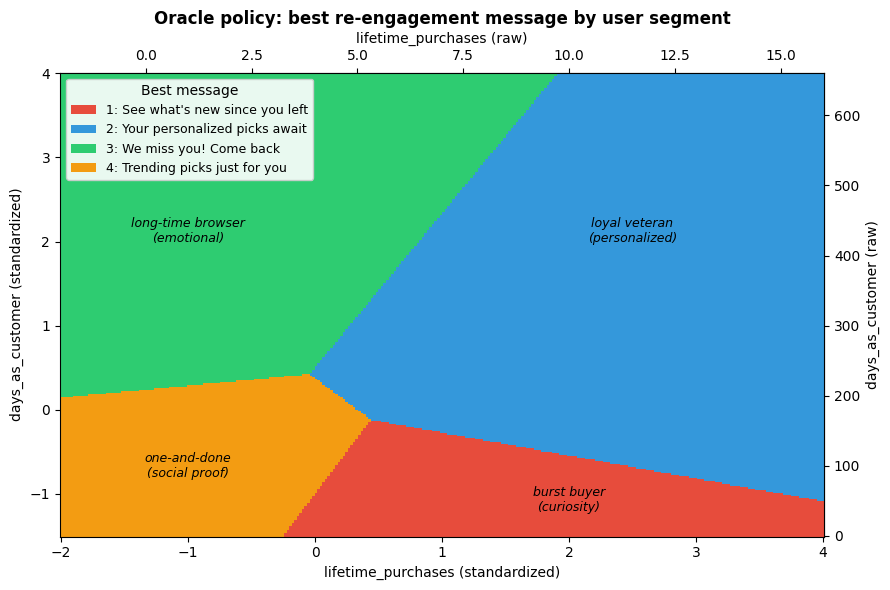

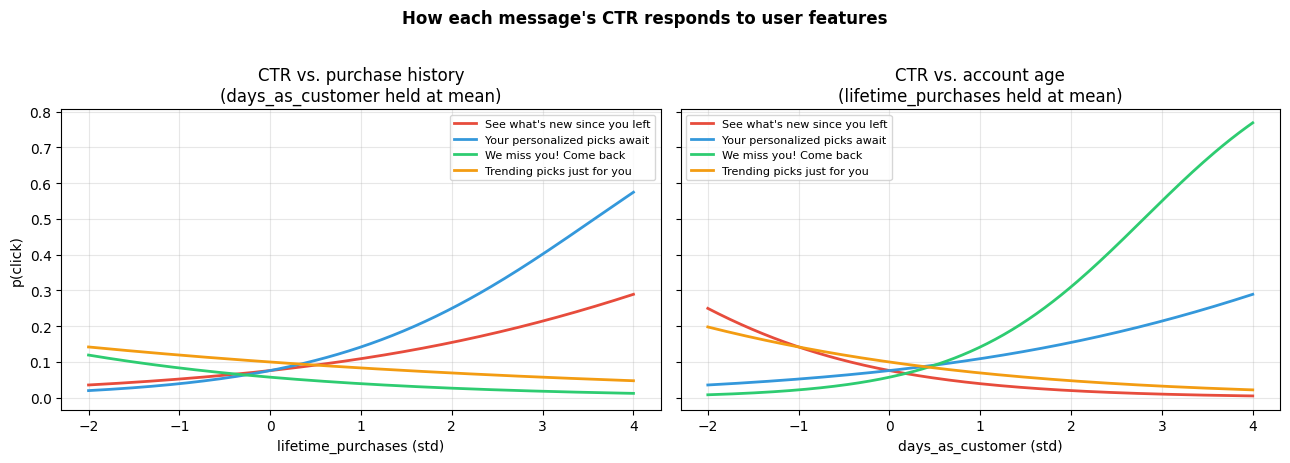

In [3]:
ACTION_COLORS = [
    "#e74c3c", "#3498db", "#2ecc71", "#f39c12",  # original 4
    "#9b59b6", "#e67e22", "#95a5a6",              # urgency, peer pressure, nostalgia
]

# ── 1. Feature distributions ─────────────────────────────────────────────────
N_viz = 5000
env_viz = BanditEnv(seed=123)
samples = [env_viz.sample_context() for _ in range(N_viz)]
raw_purchases = [s[1]["lifetime_purchases"] for s in samples]
raw_days      = [s[1]["days_as_customer"]   for s in samples]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))
ax1.hist(raw_purchases, bins=range(0, max(raw_purchases) + 2),
         edgecolor="white", alpha=0.85, color="steelblue")
ax1.set_xlabel("lifetime_purchases")
ax1.set_title(f"Purchase history  (mean={np.mean(raw_purchases):.1f})")

ax2.hist(raw_days, bins=50, edgecolor="white", alpha=0.85, color="steelblue")
ax2.set_xlabel("days_as_customer")
ax2.set_title(f"Account age  (mean={np.mean(raw_days):.0f} days)")

fig.suptitle("Dormant-user population", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── 2. Oracle best-action heatmap ────────────────────────────────────────────
ps_grid = np.linspace(-2, 4, 300)
ds_grid = np.linspace(-1.5, 4, 300)
P, D = np.meshgrid(ps_grid, ds_grid)

best = np.zeros_like(P, dtype=int)
for i in range(P.shape[0]):
    for j in range(P.shape[1]):
        x = np.array([1.0, P[i, j], D[i, j]])
        best[i, j] = env.oracle_action(x)

cmap = ListedColormap(ACTION_COLORS)

fig, ax = plt.subplots(figsize=(9, 6))
ax.pcolormesh(ps_grid, ds_grid, best, cmap=cmap, vmin=0.5, vmax=K + 0.5, shading="auto")

legend_elements = [
    Patch(facecolor=ACTION_COLORS[a - 1], label=f"{a}: {ACTION_NAMES[a]}")
    for a in range(1, K + 1)
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9,
          framealpha=0.9, title="Best message")

# Segment annotations
ax.text( 2.0, -1.2, "burst buyer\n(curiosity)", ha="center", fontsize=8, style="italic")
ax.text( 2.5,  2.0, "loyal veteran\n(personalized)", ha="center", fontsize=8, style="italic")
ax.text(-1.0,  2.0, "long-time browser\n(emotional)", ha="center", fontsize=8, style="italic")
ax.text(-1.0, -0.8, "one-and-done\n(social proof)", ha="center", fontsize=8, style="italic")
ax.text( 3.5, -1.2, "extreme impulse\n(urgency)", ha="center", fontsize=8, style="italic", color="#9b59b6")
ax.text(-1.5,  3.5, "extreme browser\n(peer pressure)", ha="center", fontsize=8, style="italic", color="#e67e22")

# Raw-value secondary axes
ax_top = ax.secondary_xaxis("top",
    functions=(lambda s: s * 3 + 4, lambda r: (r - 4) / 3))
ax_top.set_xlabel("lifetime_purchases (raw)")
ax_right = ax.secondary_yaxis("right",
    functions=(lambda s: s * 120 + 180, lambda r: (r - 180) / 120))
ax_right.set_ylabel("days_as_customer (raw)")

ax.set_xlabel("lifetime_purchases (standardized)")
ax.set_ylabel("days_as_customer (standardized)")
ax.set_title("Oracle policy: best re-engagement message by user segment", fontweight="bold")
plt.tight_layout()
plt.show()

# ── 3. CTR profiles ──────────────────────────────────────────────────────────
# Sweep each feature while holding the other at its population mean (std=0).
sweep = np.linspace(-2, 4, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for a in range(1, K + 1):
    ctrs = [sigmoid(W_TRUE[a-1] @ np.array([1.0, s, 0.0])) for s in sweep]
    ax1.plot(sweep, ctrs, label=ACTION_NAMES[a], color=ACTION_COLORS[a-1], lw=2)
ax1.set_xlabel("lifetime_purchases (std)")
ax1.set_ylabel("p(click)")
ax1.set_title("CTR vs. purchase history\n(days_as_customer held at mean)")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

for a in range(1, K + 1):
    ctrs = [sigmoid(W_TRUE[a-1] @ np.array([1.0, 0.0, s])) for s in sweep]
    ax2.plot(sweep, ctrs, label=ACTION_NAMES[a], color=ACTION_COLORS[a-1], lw=2)
ax2.set_xlabel("days_as_customer (std)")
ax2.set_title("CTR vs. account age\n(lifetime_purchases held at mean)")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

fig.suptitle("How each message's CTR responds to user features", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 2. The Bandit Learning Loop

Now we introduce the **learner** — a VowpalWabbit contextual-bandit agent that doesn't know $W_{\text{TRUE}}$ and must figure out which message works best for each user through trial and error.

### The interaction loop

On every round the system performs four steps:

1. **Observe context** — a dormant user's features arrive.
2. **Predict & explore** — the policy outputs a probability distribution over the $K$ actions and we **sample** an action from it.  The probability assigned to the chosen action is the **propensity** $\mu(a \mid x)$.
3. **Observe reward** — the environment reveals whether the user clicked (1) or not (0) *for the chosen action only* (bandit feedback — we never see outcomes for unchosen actions).
4. **Learn** — the (action, cost, propensity, features) tuple is fed back to VW so it can update its internal model.

### Exploration vs. exploitation

The policy's action distribution is controlled by $\varepsilon$-greedy exploration:

$$
\pi(a \mid x) = 
\begin{cases}
1 - \varepsilon + \dfrac{\varepsilon}{K} & \text{if } a = \arg\max_{a'} \hat{r}(x, a') \\[6pt]
\dfrac{\varepsilon}{K} & \text{otherwise}
\end{cases}
$$

where:
- $K$ is the number of actions (here $K = 7$, our message variants)
- $\hat{r}(x, a')$ is VW's **estimated reward** for action $a'$ given context $x$ — its current best guess of the CTR, learned from past observations
- $\varepsilon$ controls the explore/exploit tradeoff

In words: with probability $\varepsilon$ we **explore** (pick uniformly at random), and with probability $1 - \varepsilon$ we **exploit** (pick the action with the highest estimated reward).  The formula folds both into a single distribution — the greedy action gets the exploitation mass *plus* its share of the exploration mass.

Concrete example with $K=7$, $\varepsilon=0.1$:
- Best action: $0.9 + 0.1/7 \approx 0.914$ (91.4%)
- Each other action: $0.025$ (2.5%)

Key settings:
- $\varepsilon = 1$ → **uniform random** (pure exploration).  Every action gets $\frac{1}{K} = 0.25$.
- $\varepsilon = 0$ → **greedy** (pure exploitation).  The model always picks its current best guess.
- In practice we start with $\varepsilon = 1$ during a **warm-up phase** to collect unbiased data, then reduce $\varepsilon$ to exploit what we've learned.

### Why propensity matters — $\mu$ vs. $\pi$

Two policies appear in this notebook and it's important to keep them straight:

| Symbol | Name | Role |
|--------|------|------|
| $\mu(a \mid x)$ | **Logging / behavior policy** | The policy that *actually chose the actions* when the data was collected.  During warm-up, $\mu$ is uniform ($\varepsilon = 1$), so $\mu(a \mid x) = \frac{1}{K} = 0.25$. |
| $\pi(a \mid x)$ | **Target / candidate policy** | A *different* policy we want to evaluate or deploy (e.g. $\varepsilon = 0.05$). |

The distinction matters for **off-policy evaluation (OPE)** — estimating how $\pi$ would have performed using only data collected under $\mu$.  The key tool is the **importance weight**:

$$
w_i = \frac{\pi(a_i \mid x_i)}{\mu(a_i \mid x_i)}
$$

If $\pi$ would have chosen action $a_i$ *more often* than $\mu$ did, we upweight that observation; if less often, we downweight it.  This corrects for the mismatch between what we did ($\mu$) and what we wish we had done ($\pi$).

Recording $\mu(a \mid x)$ with every observation during data collection is what makes this correction possible.

Two common OPE estimators built on importance weights:

**IPS (Inverse Propensity Scoring)** — an unbiased estimate of $\pi$'s expected reward:

$$
\hat{V}_{\text{IPS}}(\pi) = \frac{1}{N} \sum_{i=1}^{N} w_i \cdot r_i
$$

**SNIPS (Self-Normalized IPS)** — normalizes by the sum of weights, trading a small bias for much lower variance:

$$
\hat{V}_{\text{SNIPS}}(\pi) = \frac{\sum_{i=1}^{N} w_i \cdot r_i}{\sum_{i=1}^{N} w_i}
$$

In practice SNIPS tends to give more stable estimates, which is why we use it later to select the best $\varepsilon$.

### A note on $\hat{r}$ — VW's internal model

The $\hat{r}(x, a')$ in the $\varepsilon$-greedy formula is VW's **learned reward estimate**.  Internally VW maintains a weight vector $\hat{W}[a]$ for each action and predicts:

$$
\hat{r}(x, a) = \hat{W}[a] \cdot x
$$

This is a **raw linear prediction** — no sigmoid.  Our true environment uses $\sigma(W_{\text{TRUE}}[a] \cdot x)$, but VW doesn't know that.  It doesn't need to recover the exact click probabilities — it just needs to *rank* the actions correctly for each context, and a linear model can get the ranking right without the sigmoid since $\sigma$ is monotonic (preserves ordering).

### Doubly Robust vs. IPS/SNIPS — where each is used

These are related ideas (all based on importance weighting) but applied at different stages:

| Method | When | Purpose |
|--------|------|---------|
| **Doubly Robust** (`--cb_type dr`) | During each online learning step | Helps VW estimate costs for *unchosen* actions to update its model |
| **IPS / SNIPS** | After warm-up (batch OPE) | Estimates a candidate policy's CTR from logged data to pick the best $\varepsilon$ |

#### Why not just train a classifier?

A natural first instinct is to treat this as standard supervised learning: we have a feature vector $(x, a)$ — the user's state plus which action was taken (one-hot encoded) — and a binary target (click = 1, no click = 0).  Train $\hat{r}(x, a) \approx p(\text{click} \mid x, a)$ and use it to pick the best action.

This is called the **direct method**, and it *almost* works — but breaks down once $\varepsilon < 1$.  Once the policy starts exploiting, action selection becomes **biased**: the model sends its current-best action to most users and rarely tries alternatives.  So we accumulate lots of training data for (high-purchase user, "Personalized picks") but very little for (high-purchase user, "See what's new").  The model becomes well-calibrated where it already exploits, but poorly calibrated for the actions it avoids — and it can never discover it's wrong because it rarely tries them.  This creates a **feedback loop**: biased data → biased model → more biased data.

#### How DR fixes this

On each round, VW needs a cost estimate for *every* action to do a proper gradient update — not just the one it chose.  DR constructs these estimates differently depending on whether we observed the outcome:

**For the action we took** ($a' = a_{\text{chosen}}$):

$$
\hat{c}_{\text{DR}}(a') = \hat{c}_{\text{model}}(a') + \frac{c_{\text{observed}} - \hat{c}_{\text{model}}(a')}{\mu(a \mid x)}
$$

This starts with the model's prediction, then adds an IPS-corrected residual.  If the model was right ($c_{\text{observed}} \approx \hat{c}_{\text{model}}$), the correction is tiny.  If it was wrong, the correction is large — and scaled by $1/\mu$ to account for the probability of having chosen this action.

**For actions we didn't take** ($a' \neq a_{\text{chosen}}$):

$$
\hat{c}_{\text{DR}}(a') = \hat{c}_{\text{model}}(a')
$$

We have no observed outcome, so we fall back to the model's current prediction — it's all we have.

With these "filled in" costs for all $K$ actions, VW can update $\hat{W}$ as if it had full-information feedback.

#### Why "doubly robust"?

The overall DR value estimate combines both components:

$$
\hat{V}_{\text{DR}}(\pi) = \frac{1}{N} \sum_{i=1}^{N} \left[ \hat{r}(x_i, a_i) \;+\; \frac{\pi(a_i \mid x_i)}{\mu(a_i \mid x_i)} \bigl(r_i - \hat{r}(x_i, a_i)\bigr) \right]
$$

The name comes from a nice theoretical property: the estimate is consistent if *either* the model $\hat{r}$ is accurate *or* the propensities $\mu$ are accurate.  You only get in trouble if both are wrong simultaneously.

| Approach | What it does | Weakness |
|----------|-------------|----------|
| **Direct method** | Train $\hat{r}(x,a)$, update only on observed action | Selection bias — reinforces existing beliefs |
| **Pure IPS** | Weight observed cost by $1/\mu$, ignore model | High variance — especially when $\mu$ is small |
| **DR** | Use model as baseline, IPS-correct with observed data | Robust to errors in *either* component |

**IPS / SNIPS** are simpler batch estimators we use *after* the warm-up to compare candidate policies offline.  They don't require a learned model — just the logged rewards and propensities.

### End-to-end process: how all the pieces fit together

Here's the full pipeline we run in this notebook, step by step:

---

**Phase 1 — Warm-up (pure exploration, $\varepsilon = 1$)**

> *Goal: collect unbiased training data for the model, and unbiased logs for OPE.*

1. Create a fresh VW model with $\varepsilon = 1$ (uniform random — every action gets probability $\frac{1}{K}$).
2. For each of $N$ rounds:
   - A dormant user arrives → observe context $x$
   - VW predicts action probabilities → all $0.25$ (uniform)
   - Sample an action $a$ at random, record propensity $\mu = 0.25$
   - Observe click/no-click → compute cost $= 1 - \text{click}$
   - Feed $(a, \text{cost}, \mu, x)$ back to VW → VW updates $\hat{W}$ internally (using Doubly Robust)
   - **Also** save $(x, a, \mu, \text{click})$ to a log for OPE later
3. Save the trained model to disk.

> **Why does learning during $\varepsilon = 1$ work?**  VW *is* updating $\hat{W}$ on every round, which would normally change the action probabilities.  But with $\varepsilon = 1$ the epsilon-greedy formula collapses to $\pi(a \mid x) = \frac{1}{K} = 0.25$ for all actions — the $\arg\max$ term gets zeroed out.  So the model learns quietly in the background, but the **exploration policy ignores what it learns**.  This gives us two nice properties: (1) the logged propensities are constant ($\mu = 0.25$, always exact, simplifying OPE), and (2) the saved model has reasonable $\hat{W}$ estimates ready for Phase 2.  If we used $\varepsilon < 1$ during warm-up, the changing $\hat{W}$ would shift action probabilities mid-collection, making propensities time-varying and OPE much harder.

*Output:* A warm-started model (has learned rough reward estimates from uniform data) **+** a batch of logged interactions.

---

**Phase 2 — Off-Policy Evaluation (OPE)**

> *Goal: pick the best $\varepsilon$ without deploying anything new.*

4. For each candidate $\varepsilon$ (e.g. $0.01, 0.05, 0.1, 0.2, 0.5$):
   - Load the warm-started model with that $\varepsilon$ → this gives a candidate policy $\pi_\varepsilon$
   - For every logged observation, compute the importance weight $w_i = \frac{\pi_\varepsilon(a_i \mid x_i)}{\mu(a_i \mid x_i)}$
   - Use IPS and SNIPS to estimate the CTR $\pi_\varepsilon$ *would have achieved*
5. Rank candidates by SNIPS score → pick the best $\varepsilon$.

*Output:* The $\varepsilon$ that OPE predicts will give the highest CTR (in our case, $\varepsilon = 0.01$).

---

**Phase 3 — Live deployment (exploit with minimal exploration)**

> *Goal: deploy the best policy and keep learning online.*

6. Load the warm-started model with the OPE-selected $\varepsilon$.
7. Run $N$ more rounds of the bandit loop — same 4 steps as warm-up, but now the policy *exploits* (puts ~99% probability on its best guess while still exploring 1%).
8. CTR should improve as the model continues learning and making better action choices.

*Output:* A policy that outperforms the uniform baseline — it has learned which message tone works best for which user segment.

---

> **When does online learning actually matter?**  During Phase 1 ($\varepsilon = 1$), online learning is a convenience, not a necessity — you could collect the logs with a coin flip and train a model on the batch afterward.  VW just happens to learn as it goes, giving us a warm-started model for free.  Online learning becomes *essential* in Phase 3 ($\varepsilon < 1$), where $\hat{W}$ directly controls which action the $\arg\max$ picks.  Each round's update immediately influences the next round's behavior, creating a virtuous cycle: better $\hat{W}$ → better actions → higher rewards → better $\hat{W}$.

---

```
 Phase 1: Warm-up          Phase 2: OPE              Phase 3: Live
┌─────────────────--┐    ┌────────────────-───┐    ┌──────────────────┐
│  ε = 1 (uniform)  │    │  Logged data from  │    │  ε = best (0.01) │
│                   │    │  Phase 1           │    │                  │
│  Collect data +   │-──▶│                    │-──▶│  Exploit + learn │
│  Train model      │    │  IPS / SNIPS eval  │    │  online          │
│  Save logs        │    │  Pick best ε       │    │                  │
└────────────────--─┘    └───────────────-────┘    └──────────────────┘
     ~9% CTR             (offline, no new          ~12% CTR
   (random baseline)       data needed)          (learned policy)
```

In [4]:
# Create a VW contextual-bandit learner.
# --cb_explore K  : K actions, exploration mode
# --epsilon 1.0   : pure uniform exploration (warm-up / logging policy)
# --cb_type dr    : doubly-robust cost estimation
vw = Workspace(f"--cb_explore {K} --epsilon 1.0 --cb_type dr", quiet=True)

# Single prediction: VW returns a probability distribution over actions.
x, raw = env.sample_context()
feats = vw_features(x)

probs = vw.predict(feats, prediction_type=PredictionType.ACTION_PROBS)
action, prop = sample_from_probs(probs, env.rng)

print("user:", raw)
print("VW features:", feats)
print("action probs:", probs, " sum=", sum(probs))
print(f"sampled → action {action} ({ACTION_NAMES[action]}), propensity={prop}")

user: {'lifetime_purchases': 5, 'days_as_customer': 142}
VW features: | lifetime_purchases:0.6000 days_as_customer:0.2882
action probs: [0.25, 0.25, 0.25, 0.25]  sum= 1.0
sampled → action 1 (See what's new since you left), propensity=0.25


In [5]:
# One full interaction step — the core CB loop:

x, raw = env.sample_context()
feats = vw_features(x)

# 1) VW predicts action probabilities under current policy
probs = vw.predict(feats, prediction_type=PredictionType.ACTION_PROBS)

# 2) Sample an action and record its propensity (for later OPE / learning)
action, prop = sample_from_probs(probs, env.rng)

# 3) Environment reveals the reward for the chosen action only (bandit feedback)
click = env.sample_click(x, action)
cost = 1 - click  # VW minimizes cost, so cost = 1 - reward

# 4) Feed the observation back to VW:  "action:cost:propensity | features"
vw_example = f"{action}:{cost}:{prop} {feats}"
vw.learn(vw_example)

print(f"user: {raw}")
print(f"sent: {ACTION_NAMES[action]}  (propensity={prop:.2f})")
print(f"clicked: {bool(click)}  (true p(click)={env.click_prob(x, action):.3f})")
print(f"VW training line: {vw_example}")

user: {'lifetime_purchases': 4, 'days_as_customer': 72}
sent: See what's new since you left  (propensity=0.25)
clicked: False  (true p(click)=0.094)
VW training line: 1:1:0.25 | lifetime_purchases:0.4000 days_as_customer:-0.1004


In [6]:
# Warm-up phase: epsilon=1 → uniform random exploration.
# The model is learning from scratch; every action gets equal probability.
vw_warm = Workspace(f"--cb_explore {K} --epsilon 1.0 --cb_type dr", quiet=True)
env_warm = BanditEnv(seed=42)
ctr = run_bandit(vw_warm, env_warm, N=5000, report_every=500)
print("warm-up finished CTR:", ctr)

t=  500  overall_CTR=0.090  recent_CTR=0.090  probs=[0.25 0.25 0.25 0.25]
t= 1000  overall_CTR=0.082  recent_CTR=0.074  probs=[0.25 0.25 0.25 0.25]
t= 1500  overall_CTR=0.078  recent_CTR=0.070  probs=[0.25 0.25 0.25 0.25]
t= 2000  overall_CTR=0.087  recent_CTR=0.114  probs=[0.25 0.25 0.25 0.25]
t= 2500  overall_CTR=0.090  recent_CTR=0.104  probs=[0.25 0.25 0.25 0.25]
t= 3000  overall_CTR=0.090  recent_CTR=0.086  probs=[0.25 0.25 0.25 0.25]
t= 3500  overall_CTR=0.097  recent_CTR=0.138  probs=[0.25 0.25 0.25 0.25]
t= 4000  overall_CTR=0.096  recent_CTR=0.094  probs=[0.25 0.25 0.25 0.25]
t= 4500  overall_CTR=0.096  recent_CTR=0.094  probs=[0.25 0.25 0.25 0.25]
t= 5000  overall_CTR=0.093  recent_CTR=0.062  probs=[0.25 0.25 0.25 0.25]
warm-up finished CTR: 0.0926


In [7]:
def warmup_with_logging(N=5000, report_every=500, seed=42):
    """Uniform-exploration warm-up that also saves full interaction logs for OPE."""
    vw = Workspace(f"--cb_explore {K} --epsilon 1.0 --cb_type dr", quiet=True)
    env_log = BanditEnv(seed=seed)

    xs = np.zeros((N, 2), dtype=np.float32)
    actions = np.zeros(N, dtype=np.int32)
    props = np.zeros(N, dtype=np.float32)
    clicks = np.zeros(N, dtype=np.int8)
    total_clicks = 0

    for t in range(N):
        x, _ = env_log.sample_context()
        feats = vw_features(x)

        probs = vw.predict(feats, prediction_type=PredictionType.ACTION_PROBS)
        a, p = sample_from_probs(probs, env_log.rng)

        click = env_log.sample_click(x, a)
        cost = 1 - click
        vw.learn(f"{a}:{cost}:{p} {feats}")

        xs[t] = [x[1], x[2]]
        actions[t] = a
        props[t] = p
        clicks[t] = click

        total_clicks += click
        if (t + 1) % report_every == 0:
            print(f"t={t+1:5d}  CTR={total_clicks/(t+1):.3f}  last_probs={np.round(probs, 3)}")

    logs = {"xs": xs, "actions": actions, "props": props, "clicks": clicks}
    return vw, logs

vw_warm, logs = warmup_with_logging(N=5000, report_every=1000)

print(f"\nmean logged propensity: {np.mean(logs['props']):.3f}")
print(f"unique actions: {np.unique(logs['actions'])}")
print(f"warm-up CTR: {np.mean(logs['clicks']):.4f}")

t= 1000  CTR=0.082  last_probs=[0.25 0.25 0.25 0.25]
t= 2000  CTR=0.087  last_probs=[0.25 0.25 0.25 0.25]
t= 3000  CTR=0.090  last_probs=[0.25 0.25 0.25 0.25]
t= 4000  CTR=0.096  last_probs=[0.25 0.25 0.25 0.25]
t= 5000  CTR=0.093  last_probs=[0.25 0.25 0.25 0.25]

mean logged propensity: 0.250
unique actions: [1 2 3 4]
warm-up CTR: 0.0926


In [8]:
# Save the warm-started model so we can load it with different epsilon values.
model_path = "vw_warm.model"
vw_warm.save(model_path)

def make_vw_with_epsilon(eps, model_path=model_path):
    return Workspace(f"--cb_explore {K} --epsilon {eps} --cb_type dr -i {model_path}", quiet=True)

def ope_ips_snips(vw_candidate, logs, mu=0.25):
    """
    Off-Policy Evaluation using IPS and SNIPS.

    Estimates the CTR that `vw_candidate` *would* achieve, using only the
    logged data collected under the uniform logging policy (mu).
    """
    xs, actions, clicks = logs["xs"], logs["actions"], logs["clicks"]
    N = len(actions)
    w = np.empty(N, dtype=np.float64)

    for i in range(N):
        feats = f"| lifetime_purchases:{xs[i,0]:.4f} days_as_customer:{xs[i,1]:.4f}"
        probs = vw_candidate.predict(feats, prediction_type=PredictionType.ACTION_PROBS)
        pi_ai = float(probs[int(actions[i]) - 1])
        w[i] = pi_ai / mu

    ips = float(np.mean(w * clicks))
    snips = float(np.sum(w * clicks) / np.sum(w))
    return ips, snips

# Evaluate candidate policies with different exploration rates.
eps_candidates = [0.01, 0.05, 0.1, 0.2, 0.5]
results = []
for eps in eps_candidates:
    vw_cand = make_vw_with_epsilon(eps)
    ips, snips = ope_ips_snips(vw_cand, logs, mu=0.25)
    results.append((eps, ips, snips))
    vw_cand.finish()

results_sorted = sorted(results, key=lambda t: t[2], reverse=True)
for eps, ips, snips in results_sorted:
    print(f"eps={eps:>4}  IPS={ips:.4f}  SNIPS={snips:.4f}")

best_eps = results_sorted[0][0]
print(f"\nbest epsilon by SNIPS: {best_eps}")

eps=0.01  IPS=0.1372  SNIPS=0.1405
eps=0.05  IPS=0.1353  SNIPS=0.1386
eps= 0.1  IPS=0.1331  SNIPS=0.1361
eps= 0.2  IPS=0.1286  SNIPS=0.1312
eps= 0.5  IPS=0.1151  SNIPS=0.1165

best epsilon by SNIPS: 0.01


In [9]:
# Deploy the OPE-selected policy and let it continue learning online.
vw_live = Workspace(f"--cb_explore {K} --epsilon {best_eps} --cb_type dr -i {model_path}", quiet=True)
env_live = BanditEnv(seed=99)

ctr_live = run_bandit(vw_live, env_live, N=5000, report_every=500)
print(f"\nlive phase CTR: {ctr_live:.4f}  (vs warm-up uniform baseline ~0.34)")

vw_live.finish()

t=  500  overall_CTR=0.106  recent_CTR=0.106  probs=[0.002 0.002 0.002 0.993]
t= 1000  overall_CTR=0.114  recent_CTR=0.122  probs=[0.002 0.002 0.002 0.993]
t= 1500  overall_CTR=0.113  recent_CTR=0.112  probs=[0.002 0.002 0.002 0.993]
t= 2000  overall_CTR=0.109  recent_CTR=0.096  probs=[0.002 0.002 0.993 0.002]
t= 2500  overall_CTR=0.109  recent_CTR=0.110  probs=[0.002 0.002 0.993 0.002]
t= 3000  overall_CTR=0.111  recent_CTR=0.122  probs=[0.002 0.002 0.993 0.002]
t= 3500  overall_CTR=0.114  recent_CTR=0.132  probs=[0.002 0.002 0.002 0.993]
t= 4000  overall_CTR=0.116  recent_CTR=0.126  probs=[0.002 0.002 0.002 0.993]
t= 4500  overall_CTR=0.116  recent_CTR=0.114  probs=[0.993 0.002 0.002 0.002]
t= 5000  overall_CTR=0.116  recent_CTR=0.120  probs=[0.002 0.002 0.993 0.002]

live phase CTR: 0.1160  (vs warm-up uniform baseline ~0.34)
